# Computational Exercises 6

In [10]:
import firedrake as fd
from firedrake.output import VTKFile
import numpy as np
import matplotlib.pyplot as plt

def innerL2(u,v):
    return fd.inner(u,v) * fd.dx

def innerH1(u, v):
    return (fd.inner(u,v) + fd.inner(fd.grad(u), fd.grad(v))) * fd.dx

def L2norm(u):
    return np.sqrt(fd.assemble(innerL2(u, u)))

def H1norm(u):
    return np.sqrt(fd.assemble(innerH1(u,u)))

def SolvePoisson(flag_quads, N=16, degree=1):
    msh = fd.RectangleMesh(N, N, 1.0, 1.0, quadrilateral=flag_quads)
    V = fd.FunctionSpace(msh, "CG", degree)

    x = fd.SpatialCoordinate(msh)

    mu = fd.Constant(1.0) + fd.cos(2.0 * np.pi * x[0]) * fd.cos(2.0 * np.pi * x[1])
    uex = fd.sin(2.0 * np.pi * x[0]) * fd.sin(2.0 * np.pi * x[1]) #exact u
    f = -fd.div(mu*fd.grad(uex))

    u = fd.TrialFunction(V)
    v = fd.TestFunction(V)

    a = mu * fd.inner(fd.grad(u), fd.grad(v)) * fd.dx
    L = f * v * fd.dx

    bc = fd.DirichletBC(V, uex, "on_boundary")

    uh = fd.Function(V, name=f"Solution_N={N}")
    opts={"ksp_type": "preonly", "pc_type": "lu"}
    fd.solve(a == L, uh, bcs=[bc], solver_parameters=opts)

    eh = uh - uex
    EH1 = H1norm(eh)
    EL2 = L2norm(eh)
    EInt = fd.assemble(eh * fd.dx)

    return EH1, EL2, EInt

This function returns the errors. Now we can analyse the convergence quantitatively through the error plots.

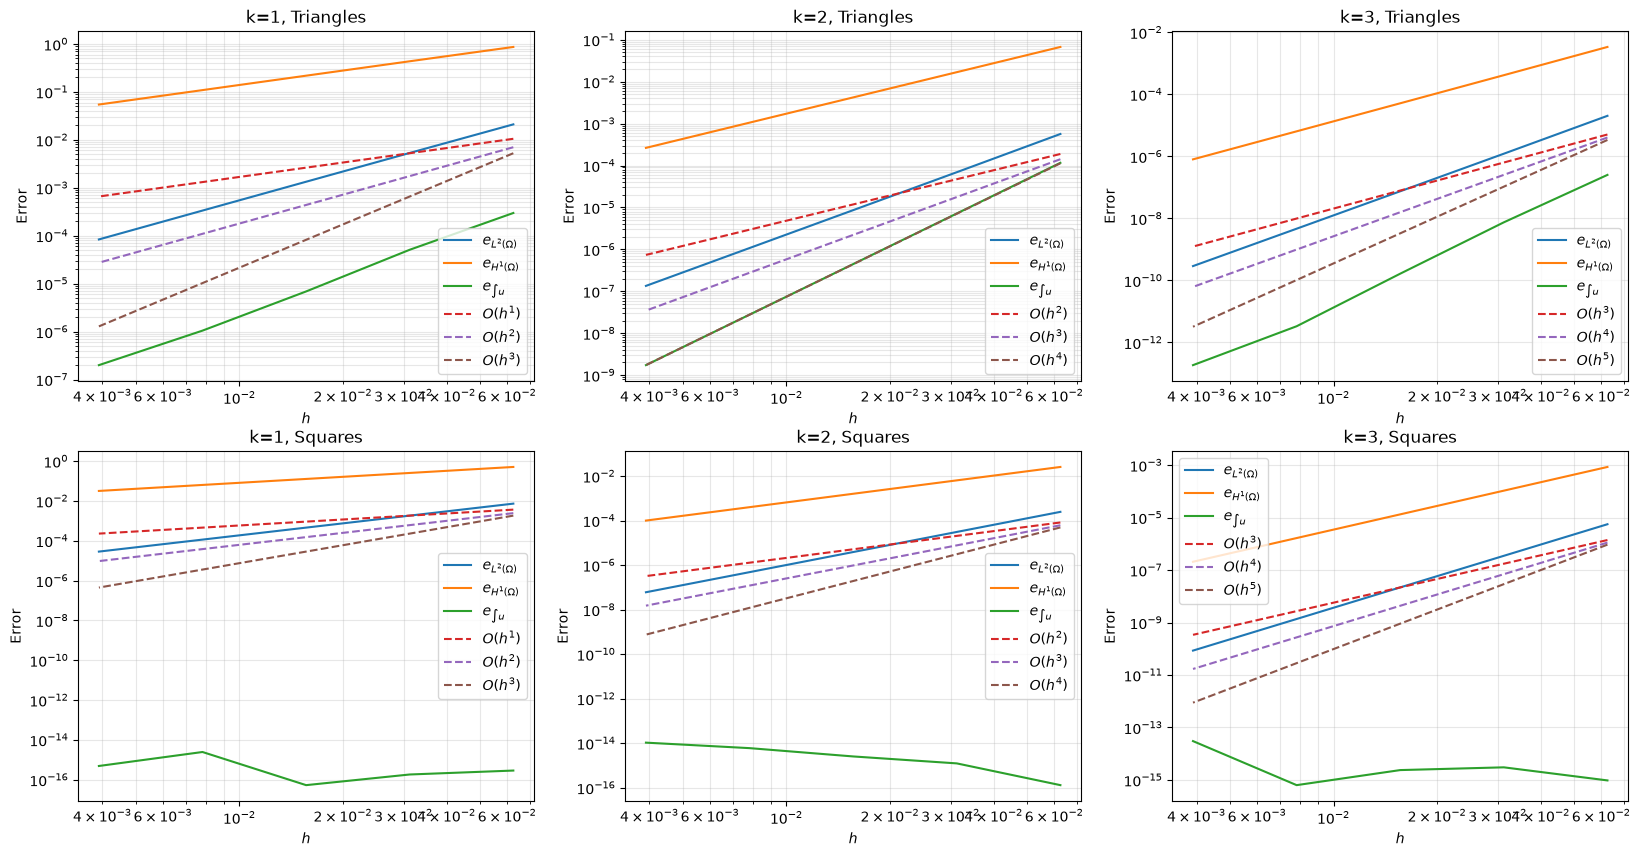

In [24]:
lquadrilaterals = [False, True]
ldeegree = [1,2,3]
lN = [16, 32, 64, 128, 256]

ig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Convergence")

for i, quad in enumerate(lquadrilaterals):
    for j, degree in enumerate(ldeegree):
        ax = axes[i, j]
        if quad == False:
            ax.set_title(f"k={degree}, Triangles")
        else:
            ax.set_title(f"k={degree}, Squares")

        hh, errsL2, errsH1, errsInt = [], [], [], []
        for N in lN:
            EH1, EL2, EInt = SolvePoisson(quad, N, degree)
            hh.append(1.0/N)
            errsL2.append(EL2)
            errsH1.append(EH1)
            errsInt.append(np.abs(EInt))

        ax.loglog(hh, errsL2, label=r"$e_{L^2(\Omega)}$")
        ax.loglog(hh, errsH1, label=r"$e_{H^1(\Omega)}$")
        ax.loglog(hh, errsInt, label=r"$e_{\int u}$")

        # Reference convergence orders, normalized at the first point
        for p in [degree, degree + 1, degree + 2]:
            ref = (1.0/(p+1)) * errsL2[0] * (np.array(hh) / hh[0])**p
            ax.loglog(
                hh, ref, "--",
                label=fr"$O(h^{p})$"
            )

        ax.legend()
        ax.set_xlabel(r"$h$")
        ax.set_ylabel("Error")
        ax.legend()
        ax.grid(True, which="both", alpha=0.3)


plt.show()


Plotting the errors alongside some reference plots we can see, analysing the slope of the curves, a pattern emerging:

In the $H^1$ norm, the convergence rate seems to be $O(h^k)$. With the $L^2$ norm, the convergence is $O(h^{k+1})$. 

Now, the integral error shows a particular behaviour. With triangles, the convergence seems to be $O(h^{k+2})$, but with squares, it looks like it hits machine precision error for any mesh size.